## Importando Datos

In [41]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda1 = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda1.head(1)

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175


In [42]:
tienda1['Tienda_ID'] = 'Tienda 1'
tienda2['Tienda_ID'] = 'Tienda 2'
tienda3['Tienda_ID'] = 'Tienda 3'
tienda4['Tienda_ID'] = 'Tienda 4'

df_total = pd.concat([tienda1, tienda2, tienda3, tienda4], ignore_index=True)

df_total['Fecha de Compra'] = pd.to_datetime(df_total['Fecha de Compra'], dayfirst=True)
df_total.head(1)

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon,Tienda_ID
0,Asistente virtual,Electrónicos,164300.0,6900.0,2021-01-16,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175,Tienda 1


## 1. Análisis de facturación

En este primer análisis, debes calcular el ingreso total de cada tienda. Sumando los valores de la columna Precio de cada conjunto de datos de la tienda para estimar los ingresos.

In [43]:
Ventas_totales = df_total.groupby('Tienda_ID')['Precio'].sum().rename('Ventas Totales')


In [44]:
for i in range(len(Ventas_totales)):
    print(f"La {Ventas_totales.index[i]} tuvo un ingreso de ${Ventas_totales.iloc[i]}")

La Tienda 1 tuvo un ingreso de $1150880400.0
La Tienda 2 tuvo un ingreso de $1116343500.0
La Tienda 3 tuvo un ingreso de $1098019600.0
La Tienda 4 tuvo un ingreso de $1038375700.0


In [45]:
Venta_promedio = df_total.groupby('Tienda_ID')['Precio'].mean().rename('Ventas Promedio')
for i in range(len(Venta_promedio)):
    print(f"La {Ventas_totales.index[i]} tuvo un ingreso por venta promedio de ${Venta_promedio.iloc[i]:.2f}")

La Tienda 1 tuvo un ingreso por venta promedio de $487867.91
La Tienda 2 tuvo un ingreso por venta promedio de $473227.43
La Tienda 3 tuvo un ingreso por venta promedio de $465459.77
La Tienda 4 tuvo un ingreso por venta promedio de $440362.89


## 2. Ventas por categoría

En este debes calcular la cantidad de productos vendidos por categoría en cada tienda. La idea es agrupar los datos por categoría y contar el número de ventas de cada tipo, mostrando las categorías más populares de cada tienda.

In [46]:
Categorias_producto_t1 = tienda1.groupby("Categoría del Producto")["Producto"].count().sort_values(ascending=False)
Categorias_ventas_t1 = tienda1.groupby("Categoría del Producto")["Precio"].sum()
Data_tienda1 = pd.merge(Categorias_producto_t1, Categorias_ventas_t1, on="Categoría del Producto")
Data_tienda1.sort_values(by="Producto", ascending=False, inplace=True)
Data_tienda1.rename(columns={'Producto': 'Cantidad', 'Precio': 'Venta'}, inplace=True)
Data_tienda1

,Cantidad,Venta
Categoría del Producto,,
Muebles,465,187633700.0
Electrónicos,448,429493500.0
Juguetes,324,17995700.0
Electrodomésticos,312,363685200.0
Deportes y diversión,284,39290000.0
Instrumentos musicales,182,91299000.0
Libros,173,8784900.0
Artículos para el hogar,171,12698400.0


In [47]:
Categorias_producto_t2 = tienda2.groupby("Categoría del Producto")["Producto"].count()
Categorias_ventas_t2 = tienda2.groupby("Categoría del Producto")["Precio"].sum()
Data_tienda2 = pd.merge(Categorias_producto_t2, Categorias_ventas_t2, on="Categoría del Producto")
Data_tienda2.sort_values(by="Producto", ascending=False, inplace=True)
Data_tienda2.rename(columns={'Producto': 'Cantidad', 'Precio': 'Venta'}, inplace=True)
Data_tienda2

,Cantidad,Venta
Categoría del Producto,,
Muebles,442,176426300.0
Electrónicos,422,410831100.0
Juguetes,313,15945400.0
Electrodomésticos,305,348567800.0
Deportes y diversión,275,34744500.0
Instrumentos musicales,224,104990300.0
Libros,197,10091200.0
Artículos para el hogar,181,14746900.0


In [48]:
Categorias_producto_t3 = tienda3.groupby("Categoría del Producto")["Producto"].count()
Categorias_ventas_t3 = tienda3.groupby("Categoría del Producto")["Precio"].sum()
Data_tienda3 = pd.merge(Categorias_producto_t3, Categorias_ventas_t3, on="Categoría del Producto")
Data_tienda3.sort_values(by="Producto", ascending=False, inplace=True)
Data_tienda3.rename(columns={'Producto': 'Cantidad', 'Precio': 'Venta'}, inplace=True)
Data_tienda3

,Cantidad,Venta
Categoría del Producto,,
Muebles,499,201072100.0
Electrónicos,451,410775800.0
Juguetes,315,19401100.0
Electrodomésticos,278,329237900.0
Deportes y diversión,277,35593100.0
Libros,185,9498700.0
Artículos para el hogar,177,15060000.0
Instrumentos musicales,177,77380900.0


In [49]:
Categorias_producto_t4 = tienda4.groupby("Categoría del Producto")["Producto"].count()
Categorias_ventas_t4 = tienda4.groupby("Categoría del Producto")["Precio"].sum()
Data_tienda4 = pd.merge(Categorias_producto_t4, Categorias_ventas_t4, on="Categoría del Producto")
Data_tienda4.sort_values(by="Producto", ascending=False, inplace=True)
Data_tienda4.rename(columns={'Producto': 'Cantidad', 'Precio': 'Venta'}, inplace=True)
Data_tienda4

,Cantidad,Venta
Categoría del Producto,,
Muebles,480,192528900.0
Electrónicos,451,409476100.0
Juguetes,338,20262200.0
Deportes y diversión,277,33350100.0
Electrodomésticos,254,283260200.0
Artículos para el hogar,201,15074500.0
Libros,187,9321300.0
Instrumentos musicales,170,75102400.0


## 3. Calificación promedio de la tienda

En este paso, debes calcular las calificaciones promedio de los clientes para cada tienda. El objetivo es conocer la satisfacción del cliente con los productos vendidos.

In [50]:
Calificacion_tiendas = df_total.groupby("Tienda_ID")["Calificación"].mean()
for i in range(len(Calificacion_tiendas)):
    print(f"La tienda {i+1} tuvo una calificación promedio de {Calificacion_tiendas.iloc[i]:.3f}")

La tienda 1 tuvo una calificación promedio de 3.977
La tienda 2 tuvo una calificación promedio de 4.037
La tienda 3 tuvo una calificación promedio de 4.048
La tienda 4 tuvo una calificación promedio de 3.996


### Tienda 1

In [51]:
Calificacion_categorias_tienda1 = tienda1.groupby("Categoría del Producto")["Calificación"].mean()
Data_tienda1 = pd.merge(Data_tienda1, Calificacion_categorias_tienda1, on="Categoría del Producto")

In [52]:
Data_tienda1.sort_values(by="Calificación", ascending=False, inplace=True)
Data_tienda1

,Cantidad,Venta,Calificación
Categoría del Producto,,,
Juguetes,324,17995700.0,4.077160
Instrumentos musicales,182,91299000.0,4.049451
Electrodomésticos,312,363685200.0,4.032051
Electrónicos,448,429493500.0,4.004464
Libros,173,8784900.0,3.976879
Muebles,465,187633700.0,3.946237
Deportes y diversión,284,39290000.0,3.897887
Artículos para el hogar,171,12698400.0,3.748538


In [53]:
pd.merge(
    tienda4.groupby("Vendedor")["Calificación"].mean(),
    tienda4.groupby("Vendedor")["Precio"].sum(),
    on="Vendedor"
).sort_values(by="Calificación", ascending=False)

,Calificación,Precio
Vendedor,,
Santiago Silva,4.160920,66510600.0
Blanca Ramirez,4.076471,78404900.0
Mariana Herrera,4.043716,62065300.0
Ángel Rodriguez,4.043210,70803800.0
Juan Fernandez,4.027174,86497500.0
Beatriz Morales,4.019108,56301900.0
Felipe Santos,4.015306,95432000.0
Rafael Acosta,4.000000,66781900.0
Lucas Olivera,3.953757,75757700.0


### Tienda 2

In [54]:
Calificacion_categorias_tienda2 = tienda2.groupby("Categoría del Producto")["Calificación"].mean()
Data_tienda2 = pd.merge(Data_tienda2, Calificacion_categorias_tienda2, on="Categoría del Producto")

In [55]:
Data_tienda2.sort_values(by="Calificación", ascending=False, inplace=True)
Data_tienda2

,Cantidad,Venta,Calificación
Categoría del Producto,,,
Muebles,442,176426300.0,4.092760
Electrodomésticos,305,348567800.0,4.072131
Artículos para el hogar,181,14746900.0,4.071823
Deportes y diversión,275,34744500.0,4.065455
Instrumentos musicales,224,104990300.0,4.035714
Juguetes,313,15945400.0,4.025559
Electrónicos,422,410831100.0,3.971564
Libros,197,10091200.0,3.949239


In [56]:
tienda2.groupby("Vendedor")["Calificación"].mean().sort_values(ascending=False).reset_index()

,Vendedor,Calificación
0,Mariana Herrera,4.191083
1,Pedro Gomez,4.169591
2,Camila Rivera,4.142857
3,Felipe Santos,4.114458
4,Maria Alfonso,4.082353
5,Ángel Rodriguez,4.065934
6,Juan Fernandez,4.055215
7,Rafael Acosta,4.013423
8,Izabela de León,4.000000
9,Beatriz Morales,3.947059


### Tienda 3

In [57]:
Calificacion_categorias_tienda3 = tienda3.groupby("Categoría del Producto")["Calificación"].mean()
Data_tienda3 = pd.merge(Data_tienda3, Calificacion_categorias_tienda3, on="Categoría del Producto")

In [58]:
Data_tienda3.sort_values(by="Calificación", ascending=False, inplace=True)
Data_tienda3

,Cantidad,Venta,Calificación
Categoría del Producto,,,
Juguetes,315,19401100.0,4.196825
Muebles,499,201072100.0,4.098196
Artículos para el hogar,177,15060000.0,4.073446
Libros,185,9498700.0,4.048649
Electrodomésticos,278,329237900.0,4.010791
Instrumentos musicales,177,77380900.0,4.005650
Electrónicos,451,410775800.0,3.986696
Deportes y diversión,277,35593100.0,3.938628


In [59]:
Calificacion_categorias_tienda4 = tienda4.groupby("Categoría del Producto")["Calificación"].mean()
Data_tienda4 = pd.merge(Data_tienda4, Calificacion_categorias_tienda4, on="Categoría del Producto")

In [60]:
Data_tienda4.sort_values(by="Calificación", ascending=False, inplace=True)
Data_tienda4

,Cantidad,Venta,Calificación
Categoría del Producto,,,
Deportes y diversión,277,33350100.0,4.054152
Libros,187,9321300.0,4.042781
Artículos para el hogar,201,15074500.0,4.009950
Electrónicos,451,409476100.0,4.006652
Muebles,480,192528900.0,3.997917
Juguetes,338,20262200.0,3.988166
Electrodomésticos,254,283260200.0,3.929134
Instrumentos musicales,170,75102400.0,3.911765


## 4. Productos más y menos vendidos

En este paso, debes identificar qué productos fueron los más vendidos y los menos vendidos en cada tienda. Visualiza los resultados para que quede claro qué productos destacaron en ventas en cada tienda.

In [61]:
df_tienda1_producto = tienda1.groupby("Producto")["Precio"].sum().sort_values(ascending=False).head(3).reset_index()
df_tienda1_producto.rename(columns={'Precio': 'Ingreso Total'}, inplace=True)
# The original line df_tienda1_producto was removed as it implicitly prints the DataFrame and is not needed if print() is used below
print("Tienda 1 - TOP 3 productos que MENOS dinero generaron:")
print(df_tienda1_producto.to_string(
        index=False, columns=['Producto', 'Ingreso Total'],
        formatters={'Ventas': '${:,.2f}'.format}
))


Tienda 1 - TOP 3 productos que MENOS dinero generaron:
     Producto  Ingreso Total
TV LED UHD 4K    142150200.0
 Refrigerador    112143300.0
    Iphone 15     97902200.0


In [62]:
df_tienda1_head = tienda1.groupby("Producto")["Categoría del Producto"].count().sort_values(ascending=False).head(3)
df_tienda1_tail = tienda1.groupby("Producto")["Categoría del Producto"].count().sort_values(ascending=False).tail(3)
Productos_tienda1 = pd.concat([df_tienda1_head, df_tienda1_tail]).reset_index()
Productos_tienda1.rename(columns={'Categoría del Producto': 'Ventas Totales'}, inplace=True)
Productos_tienda1
#Productos_tienda1.plot(kind='bar', figsize=(10,4),color='Blue',xlabel='Productos',ylabel='Ventas')

,Producto,Ventas Totales
0,Armario,60
1,TV LED UHD 4K,60
2,Microondas,60
3,Olla de presión,35
4,Celular ABXY,33
5,Auriculares con micrófono,33


In [63]:
df_tienda2_producto = tienda2.groupby("Producto")["Precio"].sum().sort_values(ascending=False).head(3).reset_index()
df_tienda2_producto.rename(columns={'Precio': 'Ingreso Total'}, inplace=True)

print("Tienda 1 - TOP 3 productos que MENOS dinero generaron:")
print(df_tienda2_producto.to_string(
        index=False, columns=['Producto', 'Ingreso Total'],
        formatters={'Ventas': '${:,.2f}'.format}
))


Tienda 1 - TOP 3 productos que MENOS dinero generaron:
     Producto  Ingreso Total
    Iphone 15    113225800.0
TV LED UHD 4K    103375000.0
 Refrigerador     97632500.0


In [64]:
df_tienda2_head = tienda2.groupby("Producto")["Categoría del Producto"].count().sort_values(ascending=False).head(3)
df_tienda2_tail = tienda2.groupby("Producto")["Categoría del Producto"].count().sort_values(ascending=False).tail(3)
Productos_tienda2 = pd.concat([df_tienda2_head, df_tienda2_tail]).reset_index()
Productos_tienda2.rename(columns={'Categoría del Producto': 'Ventas Totales'}, inplace=True)
Productos_tienda2
#Productos_tienda2.plot(kind='bar', figsize=(10,4),color='Blue',xlabel='Productos',ylabel='Ventas')

,Producto,Ventas Totales
0,Iniciando en programación,65
1,Microondas,62
2,Batería,61
3,Impresora,34
4,Mesa de comedor,34
5,Juego de mesa,32


In [65]:
df_tienda3_producto = tienda3.groupby("Producto")["Precio"].sum().sort_values(ascending=False).head(3).reset_index()
df_tienda3_producto.rename(columns={'Precio': 'Ingreso Total'}, inplace=True)

print("Tienda 1 - TOP 3 productos que MENOS dinero generaron:")
print(df_tienda3_producto.to_string(
        index=False, columns=['Producto', 'Ingreso Total'],
        formatters={'Ventas': '${:,.2f}'.format}
))


Tienda 1 - TOP 3 productos que MENOS dinero generaron:
     Producto  Ingreso Total
 Refrigerador     99889700.0
TV LED UHD 4K     96669100.0
    Iphone 15     93225700.0


In [66]:
df_tienda3_head = tienda3.groupby("Producto")["Categoría del Producto"].count().sort_values(ascending=False).head(3)
df_tienda3_tail = tienda3.groupby("Producto")["Categoría del Producto"].count().sort_values(ascending=False).tail(3)
Productos_tienda3 = pd.concat([df_tienda3_head, df_tienda3_tail]).reset_index()
Productos_tienda3.rename(columns={'Categoría del Producto': 'Ventas Totales'}, inplace=True)
Productos_tienda3
#Productos_tienda3.plot(kind='bar', figsize=(10,4),color='Blue',xlabel='Productos',ylabel='Ventas')

,Producto,Ventas Totales
0,Kit de bancas,57
1,Mesa de comedor,56
2,Cama king,56
3,Microondas,36
4,Set de vasos,36
5,Bloques de construcción,35


In [67]:
df_tienda4_producto = tienda4.groupby("Producto")["Precio"].sum().sort_values(ascending=False).head(3).reset_index()
df_tienda4_producto.rename(columns={'Precio': 'Ingreso Total'}, inplace=True)

print("Tienda 1 - TOP 3 productos que MENOS dinero generaron:")
print(df_tienda4_producto.to_string(
        index=False, columns=['Producto', 'Ingreso Total'],
        formatters={'Ventas': '${:,.2f}'.format}
))


Tienda 1 - TOP 3 productos que MENOS dinero generaron:
     Producto  Ingreso Total
    Iphone 15     96697500.0
TV LED UHD 4K     90295300.0
     Smart TV     82790400.0


In [68]:
df_tienda4_head = tienda4.groupby("Producto")["Categoría del Producto"].count().sort_values(ascending=False).head(3)
df_tienda4_tail = tienda4.groupby("Producto")["Categoría del Producto"].count().sort_values(ascending=False).tail(3)
Productos_tienda4 = pd.concat([df_tienda4_head, df_tienda4_tail]).reset_index()
Productos_tienda4.rename(columns={'Categoría del Producto': 'Ventas Totales'}, inplace=True)
Productos_tienda4
#Productos_tienda4.plot(kind='bar', figsize=(10,4),color='Blue',xlabel='Productos',ylabel='Ventas')


,Producto,Ventas Totales
0,Cama box,62
1,Cubertería,59
2,Cama king,56
3,Guitarra acústica,37
4,Armario,34
5,Guitarra eléctrica,33


## 5. Valor del envío promedio por tienda

En este paso, debes calcular el costo de envío promedio para cada tienda. El objetivo es comprender cuánto se gasta, en promedio, en el envío de cada tienda.  Sabiendo que el cliente paga el envío.

In [69]:
Promedio_envio_tiendas = [tienda1["Costo de envío"].mean(), tienda2["Costo de envío"].mean(), tienda3["Costo de envío"].mean(), tienda4["Costo de envío"].mean()]


for i in range(len(Promedio_envio_tiendas)):
    print(f"La tienda {i+1} tuvo un promedio de ${Promedio_envio_tiendas[i]:.2f}")

La tienda 1 tuvo un promedio de $26018.61
La tienda 2 tuvo un promedio de $25216.24
La tienda 3 tuvo un promedio de $24805.68
La tienda 4 tuvo un promedio de $23459.46


## 6. Generando gráfico

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

In [71]:
def plot_bar_chart(data, title, xlabel, ylabel):
    colores = []

    for i in range(len(data)):
        if data.iloc[i] == data.min():
            colores.insert(i, 'Red')
            #break
        else:
            colores.insert(i, 'Blue')

    plt.figure(figsize=(len(data)*1.75,5))
    data.plot(kind='bar', color = colores)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

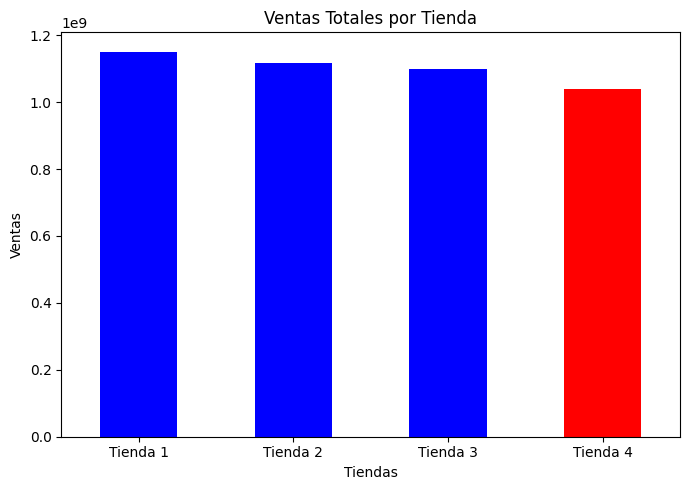

In [72]:
plot_bar_chart(Ventas_totales, "Ventas Totales por Tienda", "Tiendas", "Ventas")

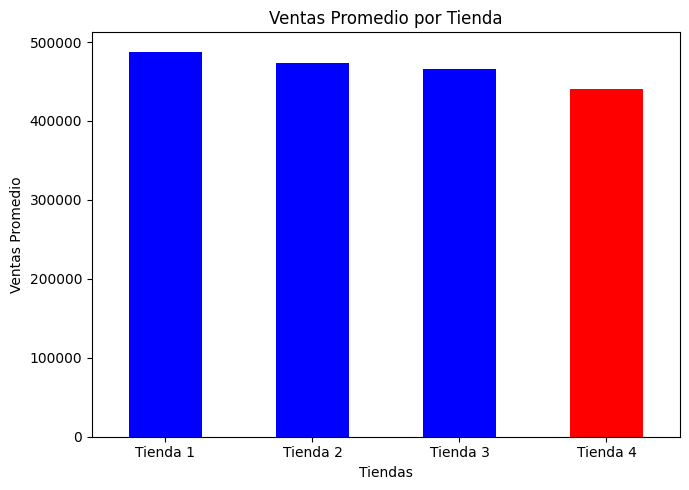

In [73]:
plot_bar_chart(Venta_promedio, "Ventas Promedio por Tienda", "Tiendas", "Ventas Promedio")
#

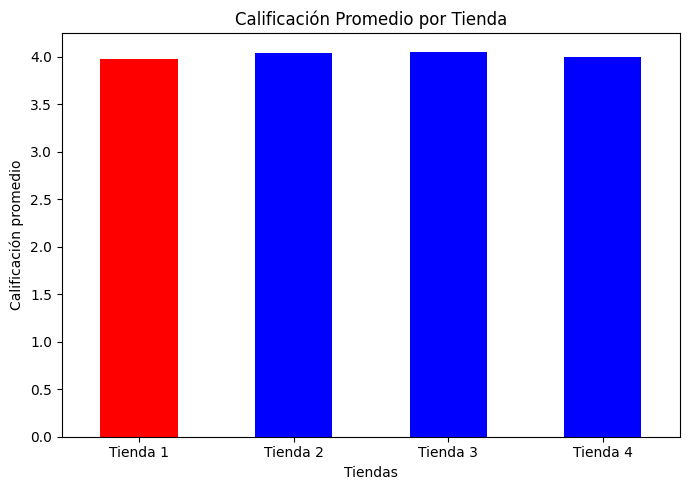

In [74]:
plot_bar_chart(Calificacion_tiendas, "Calificación Promedio por Tienda", "Tiendas", "Calificación promedio")

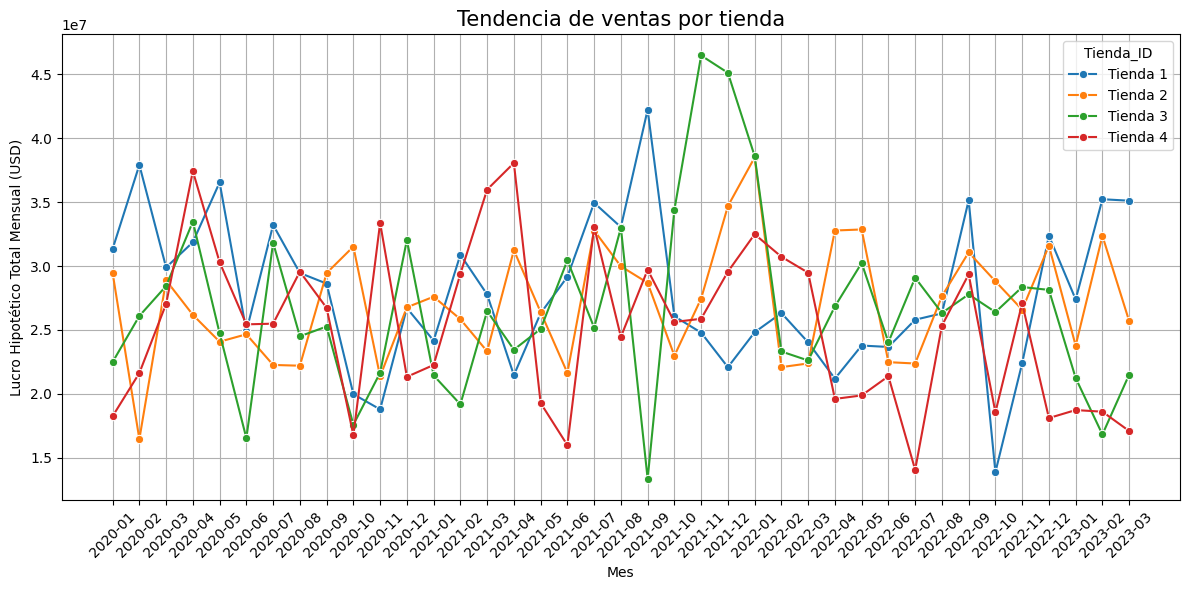

In [75]:

df_total['Lucro_Hipotetico'] = df_total['Precio'] - df_total['Costo de envío']


lucro_mensual = df_total.groupby([df_total['Fecha de Compra'].dt.to_period('M'), 'Tienda_ID' ])['Lucro_Hipotetico'].sum().reset_index()


ventas_mensuales = df_total.groupby([df_total['Fecha de Compra'].dt.to_period('M'), 'Tienda_ID'])['Precio'].sum().reset_index()

ventas_mensuales.columns = ['Fecha', 'Tienda', 'Ingresos_Mensuales']
ventas_mensuales['Fecha'] = ventas_mensuales['Fecha'].dt.to_timestamp()
ventas_mensuales = ventas_mensuales.set_index('Fecha')


lucro_mensual['Fecha de Compra'] = lucro_mensual['Fecha de Compra'].astype(str)


plt.figure(figsize=(12, 6))

sns.lineplot(data=lucro_mensual, x='Fecha de Compra', y='Lucro_Hipotetico', hue='Tienda_ID', marker='o')
plt.title('Tendencia de ventas por tienda', fontsize=15)
plt.ylabel('Lucro Hipotético Total Mensual (USD)')
plt.xlabel('Mes')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

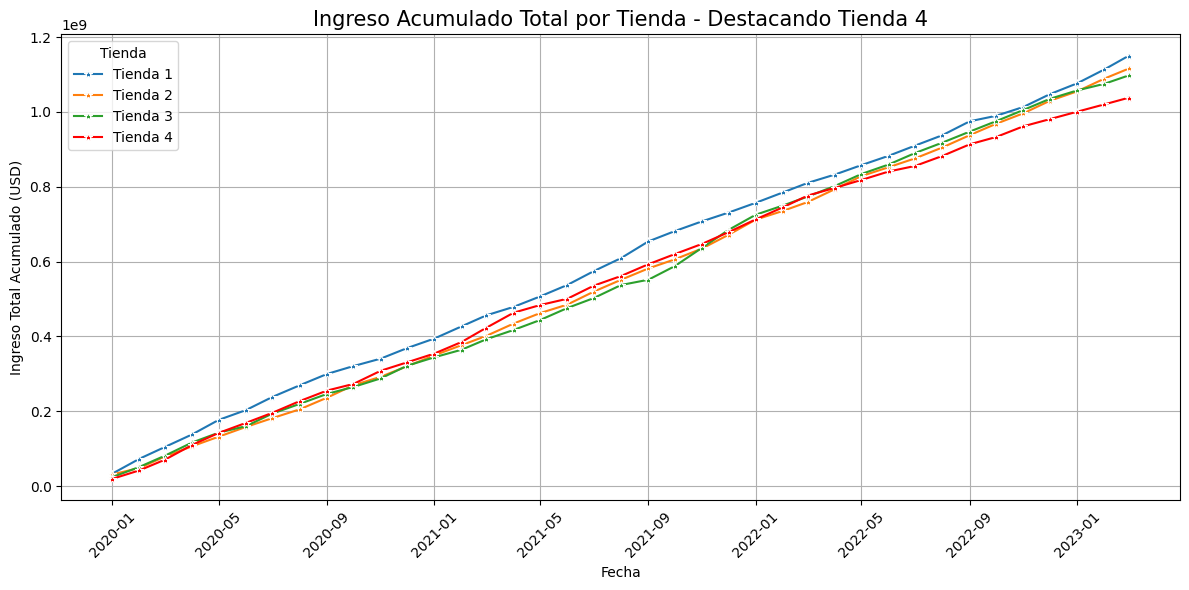

In [76]:

color_map = {'Tienda 1': '#1f77b4', 'Tienda 2': '#ff7f0e', 'Tienda 3': '#2ca02c', 'Tienda 4': 'red'}

plt.figure(figsize=(12, 6))


for tienda in ventas_mensuales['Tienda'].unique():
    data_tienda = ventas_mensuales[ventas_mensuales['Tienda'] == tienda].copy()
    data_tienda['Ingreso_Acumulado'] = data_tienda['Ingresos_Mensuales'].cumsum()
    sns.lineplot(data=data_tienda, x=data_tienda.index, y='Ingreso_Acumulado', label=tienda, marker='*', color=color_map[tienda])

plt.title('Ingreso Acumulado Total por Tienda - Destacando Tienda 4', fontsize=15)
plt.ylabel('Ingreso Total Acumulado (USD)')
plt.xlabel('Fecha')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend(title='Tienda')
plt.tight_layout()
plt.show()

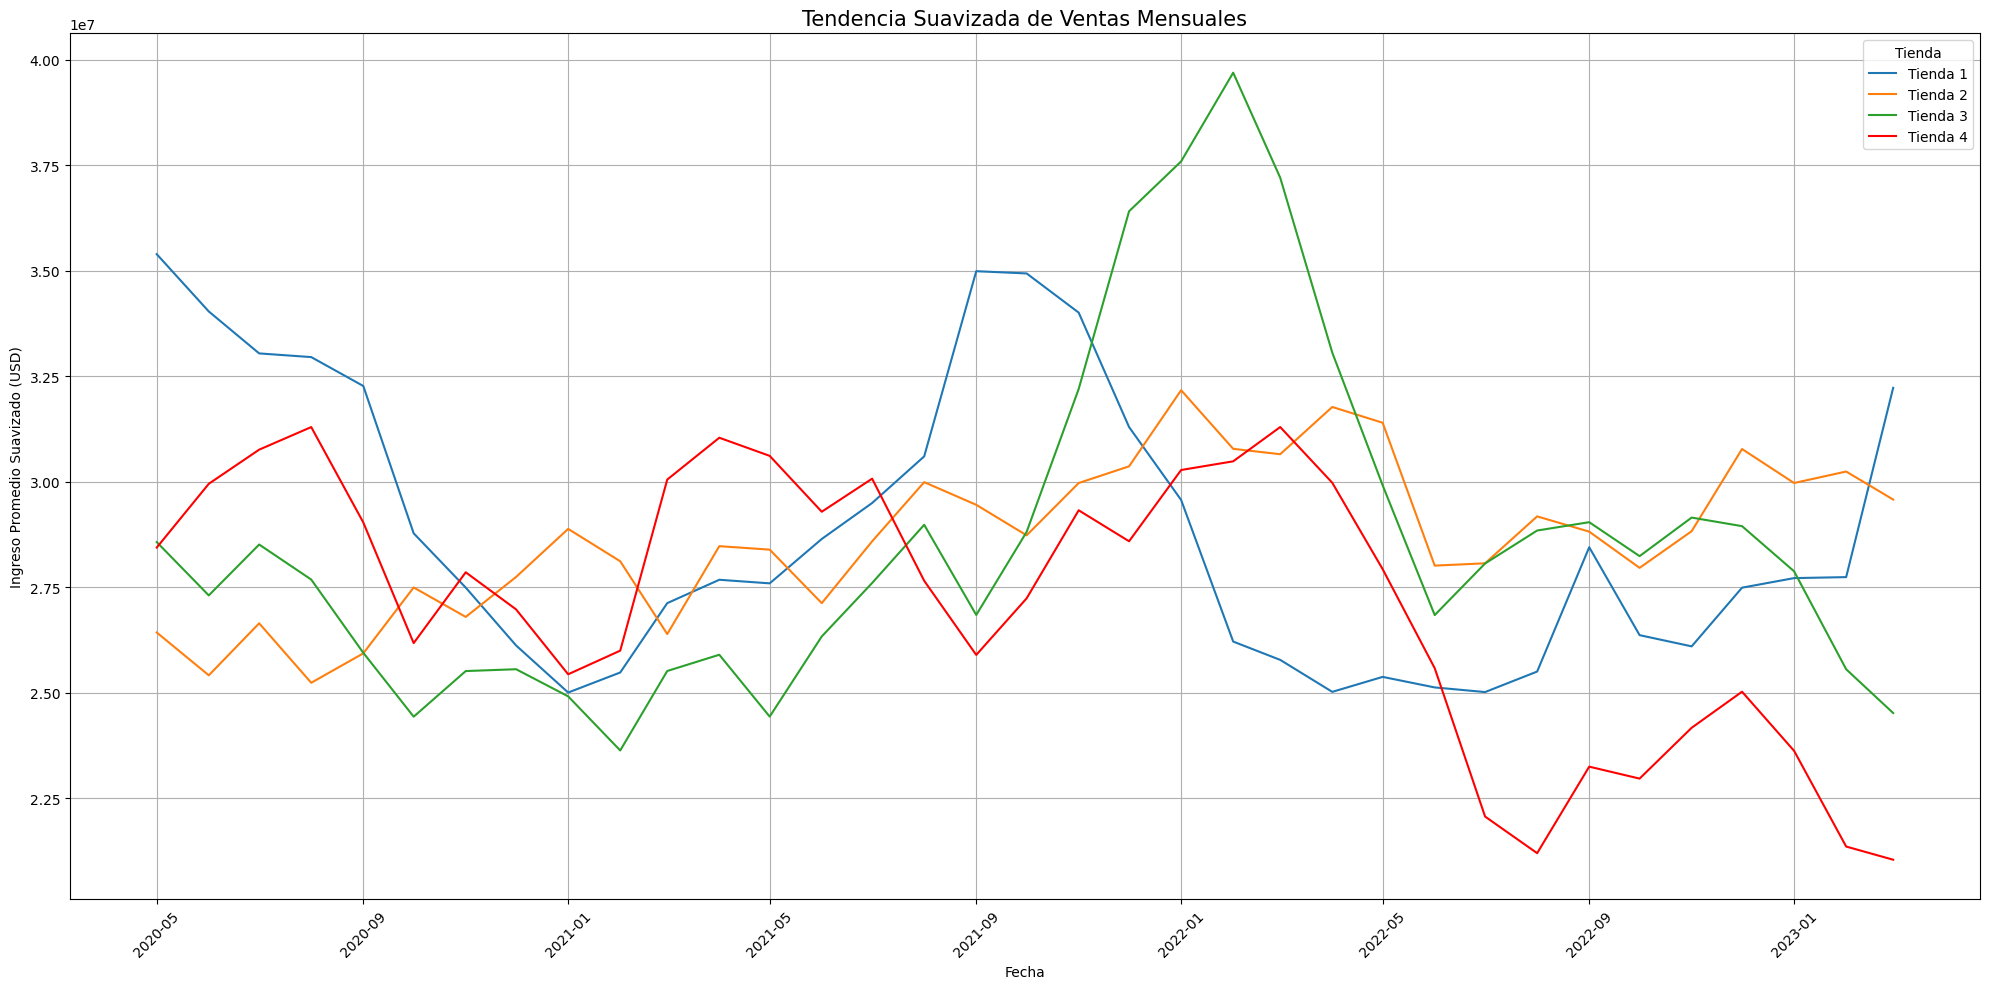

In [77]:

df_total['Fecha de Compra'] = pd.to_datetime(df_total['Fecha de Compra'], dayfirst=True)

ventas_mensuales = df_total.groupby(
    [df_total['Fecha de Compra'].dt.to_period('M'), 'Tienda_ID']
)['Precio'].sum().reset_index()


ventas_mensuales.columns = ['Fecha', 'Tienda', 'Ingresos_Mensuales']

ventas_mensuales['Fecha'] = ventas_mensuales['Fecha'].dt.to_timestamp()
ventas_mensuales = ventas_mensuales.set_index('Fecha')


color_map = {'Tienda 1': '#1f77b4', 'Tienda 2': '#ff7f0e', 'Tienda 3': '#2ca02c', 'Tienda 4': 'red'}

plt.figure(figsize=(20, 10))

for tienda in ventas_mensuales['Tienda'].unique():
    data_tienda = ventas_mensuales[ventas_mensuales['Tienda'] == tienda].copy()
    data_tienda['Media_Movil_6M'] = data_tienda['Ingresos_Mensuales'].rolling(window=5).mean()

    sns.lineplot(data=data_tienda, x=data_tienda.index, y='Media_Movil_6M',
                 label=tienda, marker='', color=color_map[tienda])

plt.title('Tendencia Suavizada de Ventas Mensuales', fontsize=15)
plt.ylabel('Ingreso Promedio Suavizado (USD)')
plt.xlabel('Fecha')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend(title='Tienda')
plt.tight_layout()
plt.show()

## 7. Informe final

**Informe de análisis de desempeño de las tiendas del Sr. Juan**

**Introducción**

El presente informe tiene como objetivo analizar el desempeño de las cuatro tiendas propiedad del Sr. Juan con el fin de identificar cuál presenta los resultados menos favorables y debería considerarse para su venta. Para realizar este análisis se evaluaron distintos indicadores relevantes, tales como los ingresos totales de cada tienda, las categorías de productos más y menos vendidas, las calificaciones promedio otorgadas por los clientes, los productos con mayor y menor volumen de ventas, así como el coste promedio de envío.

El análisis de estos factores permite comprender el rendimiento comercial de cada tienda y tomar una decisión estratégica basada en datos.

**Desarrollo del análisis**

En primer lugar, se analizaron los **ingresos totales generados por cada tienda**, lo que permitió identificar cuáles tienen un mayor volumen de ventas y cuáles presentan un rendimiento más bajo. Este indicador es fundamental para evaluar la rentabilidad de cada establecimiento.

Posteriormente, se revisaron las **categorías de productos más y menos vendidas**, lo que permitió observar el comportamiento de compra de los clientes y la rotación de productos en cada tienda. Las tiendas con mayor diversidad y volumen de ventas en categorías populares tienden a mostrar un mejor desempeño.

También se evaluaron las calificaciones promedio de los clientes, ya que estas reflejan el nivel de satisfacción con la experiencia de compra, el servicio recibido y la calidad de los productos ofrecidos.

Adicionalmente, se analizaron los productos más y menos vendidos, lo que permitió identificar tendencias de consumo y posibles oportunidades de mejora en la oferta de productos.

Finalmente, se consideró el **coste promedio de envío**, ya que este factor puede influir en la decisión de compra de los clientes y en la competitividad de cada tienda.

**Conclusión**

Con base en el análisis de todos los indicadores evaluados y en las visualizaciones generadas durante el estudio, se observa que la **Tienda 4** presenta el desempeño más bajo en comparación con las demás tiendas. Esta tienda muestra resultados menos favorables en aspectos clave como ingresos totales, rotación de productos y otros indicadores analizados.

Por esta razón, se recomienda que el Sr. Juan considere **vender la Tienda 4**, ya que su rendimiento es inferior al de las otras tiendas. Esta decisión permitiría optimizar los recursos y concentrar los esfuerzos en las tiendas con mejor desempeño y mayor potencial de crecimiento.